# PPO Synthetic vs Real: Multi-Test Experiment

This notebook is the interactive control panel and result report for the multi-window experiment. Long-running full training should normally run from a terminal; this notebook calls the same Python API when an interactive smoke run is useful.

The three training groups remain unchanged:

- real only;
- synthetic only, with equal probability across paths; and
- real + synthetic, with 50% real probability and the remaining 50% divided equally across synthetic paths.

Every checkpoint is selected on real validation data and evaluated on the matching untouched real test period.

The report below emphasizes the continuous out-of-sample chain: chronological test returns and actual portfolio weights are joined on the real date axis while portfolio value and holdings carry across test boundaries. Internal window IDs remain available in the data but are intentionally omitted from figures.

## Recommended server workflow

Run training in a terminal, then reopen this notebook to inspect the saved suite:

```bash
python -m finrl.experiments.run_synthetic_vs_real \
  --config configs/synthetic_vs_real.json \
  --mode full
```

Use repeated `--window <name>` and `--ticker-group <name>` arguments to select experiment cases. The terminal runner writes `latest_suite.json`, which this notebook discovers automatically.

In [1]:
from __future__ import annotations

import os
from pathlib import Path
import sys

from IPython.display import display
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd


def bootstrap_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / 'finrl').is_dir() and (candidate / 'examples').is_dir():
            return candidate
    raise RuntimeError('Could not locate the FinRL project root.')


PROJECT_ROOT = bootstrap_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from finrl.experiments.notebook_utils import environment_flag
from finrl.experiments.notebook_utils import performance_metrics_from_values
from finrl.experiments.synthetic_vs_real import load_experiment_config
from finrl.experiments.synthetic_vs_real import load_real_market_data
from finrl.experiments.synthetic_vs_real import run_experiment_suite
from finrl.experiments.synthetic_vs_real_plots import load_suite_artifacts
from finrl.experiments.synthetic_vs_real_plots import plot_learning_curves

plt.rcParams.update(
    {
        'figure.dpi': 120,
        'savefig.dpi': 160,
        'font.size': 12.5,
        'axes.titlesize': 15,
        'axes.labelsize': 12.5,
        'xtick.labelsize': 10.5,
        'ytick.labelsize': 10.5,
        'legend.fontsize': 10.5,
        'legend.title_fontsize': 10.5,
        'axes.edgecolor': '#4B5563',
        'axes.labelcolor': '#1F2937',
        'text.color': '#111827',
        'grid.color': '#D1D5DB',
        'grid.alpha': 0.35,
    }
)
pd.set_option('display.max_columns', 50)

print('project root:', PROJECT_ROOT)

project root: /Users/chuanwei/Files/Projects/nycu_fintech/FinRL_Exp


## 1. Configuration

Edit time splits, named ticker universes, and `active_ticker_groups` in `configs/synthetic_vs_real.json`. By default this notebook loads existing results. Set `FINRL_RUN_EXPERIMENT=1` only for an intentional interactive smoke or full run.

In [2]:
CONFIG_PATH = PROJECT_ROOT / os.getenv(
    'FINRL_EXPERIMENT_CONFIG', 'configs/synthetic_vs_real.json'
)
RUN_MODE = os.getenv('FINRL_RUN_MODE', 'full').lower()
RUN_EXPERIMENT = environment_flag('FINRL_RUN_EXPERIMENT', False)
USE_TRAIN_CACHE = environment_flag('FINRL_USE_TRAIN_CACHE', True)
FORCE_RETRAIN = environment_flag('FINRL_FORCE_RETRAIN', False)
SELECTED_WINDOWS = None  # Example: ['2024_train_val__2025_test']
SELECTED_TICKER_GROUPS = None  # Example: ['tech_5', 'chosen_10']

config = load_experiment_config(CONFIG_PATH)
settings = config.resolve_run_settings(RUN_MODE)
split_summary = pd.DataFrame(
    [
        {
            'window_id': split.name,
            'ticker_group': ticker_group,
            'tickers': ', '.join(tickers),
            'synthetic_period': split.synthetic_period_id,
            'train': f'[{split.train_start}, {split.train_end})',
            'validation': f'[{split.val_start}, {split.val_end})',
            'test': f'[{split.test_start}, {split.test_end})',
        }
        for split in config.select_splits(SELECTED_WINDOWS)
        for ticker_group, tickers in config.select_ticker_groups(
            SELECTED_TICKER_GROUPS
        )
    ]
)
print('mode:', RUN_MODE)
print('seeds:', settings.seeds)
print('timesteps:', f'{settings.total_timesteps:,}')
print('commissions:', settings.commission_map)
print('interactive execution:', RUN_EXPERIMENT)
if split_summary.empty:
    print('windows: generated from the rolling schedule at run time')
else:
    display(split_summary)

mode: full
seeds: (0,)
timesteps: 200,000
commissions: {'no_fee': 0.0, 'with_fee': 0.0025}
interactive execution: False
windows: generated from the rolling schedule at run time


## 2. Run or load the suite

When training is disabled, the notebook reads the latest terminal-produced suite for the selected mode.

In [3]:
artifact_root = PROJECT_ROOT / config.artifact_dir
latest_suite_path = artifact_root / RUN_MODE / 'latest_suite.json'

if RUN_EXPERIMENT:
    suite_result = run_experiment_suite(
        project_root=PROJECT_ROOT,
        config=config,
        mode=RUN_MODE,
        split_names=SELECTED_WINDOWS,
        ticker_group_names=SELECTED_TICKER_GROUPS,
        use_cache=USE_TRAIN_CACHE,
        force_retrain=FORCE_RETRAIN,
        show_progress=True,
    )
    manifest_path = suite_result.manifest_path
elif latest_suite_path.is_file():
    manifest_path = latest_suite_path
else:
    manifest_path = None

if manifest_path is None:
    artifacts = None
    print('No saved suite found. Run the terminal command above first.')
else:
    artifacts = load_suite_artifacts(manifest_path)
    print('manifest:', artifacts.manifest_path)
    print('experiment cases:', artifacts.experiment_cases)

manifest: /Users/chuanwei/Files/Projects/nycu_fintech/FinRL_Exp/results/ppo_synthetic_vs_real/full/suites/d192ef8f6ff2/manifest.json
experiment cases: (('wf_504_126_63_000__test_20200706_20201001', 'chosen_10'), ('wf_504_126_63_001__test_20201002_20201231', 'chosen_10'), ('wf_504_126_63_002__test_20210104_20210405', 'chosen_10'), ('wf_504_126_63_003__test_20210406_20210702', 'chosen_10'), ('wf_504_126_63_004__test_20210706_20211001', 'chosen_10'), ('wf_504_126_63_005__test_20211004_20211231', 'chosen_10'), ('wf_504_126_63_006__test_20220103_20220401', 'chosen_10'), ('wf_504_126_63_007__test_20220404_20220705', 'chosen_10'), ('wf_504_126_63_008__test_20220706_20221003', 'chosen_10'), ('wf_504_126_63_009__test_20221004_20230103', 'chosen_10'), ('wf_504_126_63_010__test_20230104_20230404', 'chosen_10'), ('wf_504_126_63_011__test_20230405_20230706', 'chosen_10'), ('wf_504_126_63_012__test_20230707_20231004', 'chosen_10'), ('wf_504_126_63_013__test_20231005_20240104', 'chosen_10'), ('wf_504

## 3. Data and test summaries

In [4]:
if artifacts is not None:
    data_summaries = pd.concat(
        [
            artifacts.read_window_csv(
                window_id, 'data_summary.csv', ticker_group=ticker_group
            )
            for window_id, ticker_group in artifacts.experiment_cases
        ],
        ignore_index=True,
    )
    data_coverage = (
        data_summaries.groupby(
            ['ticker_group', 'source', 'split'], sort=False, as_index=False
        )
        .agg(
            test_periods=('window_id', 'nunique'),
            paths=('paths', 'max'),
            first_date=('first_date', 'min'),
            last_date=('last_date', 'max'),
        )
        .rename(
            columns={
                'ticker_group': 'Ticker group',
                'source': 'Data source',
                'split': 'Split',
                'test_periods': 'Periods',
                'paths': 'Paths',
                'first_date': 'First date',
                'last_date': 'Last date',
            }
        )
    )
    display(
        data_coverage.style.hide(axis='index')
        .set_caption('Data coverage across the saved suite')
        .set_table_styles(
            [
                {'selector': 'caption', 'props': [('font-size', '15px'), ('font-weight', '600'), ('text-align', 'left')]},
                {'selector': 'th', 'props': [('font-size', '12px'), ('text-align', 'left')]},
                {'selector': 'td', 'props': [('font-size', '12px'), ('text-align', 'left')]},
            ]
        )
    )
    print(f'{len(data_summaries):,} source-summary rows across {len(artifacts.experiment_cases)} experiment cases')

198 source-summary rows across 18 experiment cases


Ticker group,Data source,Split,Periods,Paths,First date,Last date
chosen_10,Real data,train,18,1,2018-01-02,2024-04-05
chosen_10,Real data,validation,18,1,2020-01-03,2024-10-04
chosen_10,Real data,test,18,1,2020-07-06,2024-12-31
chosen_10,CN-Diff (50 paths),synthetic train,18,53,2018-01-02,2024-04-05
chosen_10,CN-Diff (50 paths),synthetic validation,18,53,2020-01-03,2024-10-04
chosen_10,NS-Diff (50 paths),synthetic train,18,50,2018-01-02,2024-04-05
chosen_10,NS-Diff (50 paths),synthetic validation,18,50,2020-01-03,2024-10-04
chosen_10,ARMD (Direct),synthetic train,18,1,2018-01-02,2024-04-05
chosen_10,ARMD (Direct),synthetic validation,18,1,2020-01-03,2024-10-04
chosen_10,ARMD (Returns),synthetic train,18,1,2018-01-02,2024-04-05


## 4. Continuous out-of-sample test return

All chronological test periods are joined on the real date axis. PPO lines are cross-seed means with observed seed ranges; the two deterministic equal-weight benchmarks are drawn as reference lines. No window IDs are drawn.

Sortino uses a zero daily minimum acceptable return and 252-day annualized downside deviation. Calmar is CAGR divided by the absolute maximum drawdown.


In [5]:
PLOT_COMMISSION = os.getenv('FINRL_PLOT_COMMISSION', 'with_fee')
REQUESTED_TICKER_GROUP = os.getenv('FINRL_PLOT_TICKER_GROUP')
PLOT_TICKER_GROUP = (
    artifacts.select_ticker_group(REQUESTED_TICKER_GROUP)
    if artifacts is not None
    else None
)

HAS_CONTINUOUS = (
    artifacts is not None
    and not artifacts.continuous_metrics.empty
    and not artifacts.continuous_window_metrics.empty
    and not artifacts.continuous_daily_returns.empty
    and not artifacts.continuous_equity_curves.empty
    and not artifacts.continuous_portfolio_weights.empty
)

TABLE_STYLES = [
    {
        'selector': 'caption',
        'props': [
            ('font-size', '15px'),
            ('font-weight', '600'),
            ('text-align', 'left'),
            ('padding-bottom', '8px'),
        ],
    },
    {
        'selector': 'th',
        'props': [('font-size', '12px'), ('text-align', 'right')],
    },
    {
        'selector': 'td',
        'props': [('font-size', '12px'), ('text-align', 'right')],
    },
]


def show_table(frame, *, caption, formats=None, highlight=None):
    styled = (
        frame.style.hide(axis='index')
        .format(formats or {}, na_rep='—')
        .set_caption(caption)
        .set_table_styles(TABLE_STYLES)
    )
    if highlight:
        styled = styled.background_gradient(subset=highlight, cmap='Blues')
    display(styled)


def suite_slice(frame):
    return frame.loc[
        (frame['ticker_group'] == PLOT_TICKER_GROUP)
        & (frame['commission_name'] == PLOT_COMMISSION)
    ].copy()


if HAS_CONTINUOUS:
    continuous_metrics = suite_slice(artifacts.continuous_metrics)
    continuous_windows = suite_slice(artifacts.continuous_window_metrics)
    continuous_daily = suite_slice(artifacts.continuous_daily_returns)
    continuous_curves = suite_slice(artifacts.continuous_equity_curves)
    continuous_weights = suite_slice(artifacts.continuous_portfolio_weights)
    if any(
        frame.empty
        for frame in (
            continuous_metrics,
            continuous_windows,
            continuous_daily,
            continuous_curves,
            continuous_weights,
        )
    ):
        raise ValueError(
            f'No continuous artifacts for {PLOT_TICKER_GROUP}, {PLOT_COMMISSION}'
        )
    POLICY_GROUP_ORDER = list(dict.fromkeys(continuous_metrics['group']))
    COMMISSION_RATE = float(settings.commission_map[PLOT_COMMISSION])
else:
    print('Continuous artifacts are unavailable; run a complete chronological suite.')

### Benchmark definitions

- **Buy & Hold — equal weight at start:** allocate equal capital to every stock once, immediately before the first OOS test day, pay the initial purchase fee, and never rebalance.
- **Dynamic Equal Weight:** start from the same equal allocation, then rebalance to equal stock weights at every OOS close. The selected commission is charged on L1 turnover.

Both benchmarks span the complete chronological OOS chain without resetting at internal test boundaries. They use the same adjusted close data, ticker universe, initial capital, and fee setting as the experiment.

In [6]:
BENCHMARK_GROUPS = ('buy_and_hold_equal_start', 'dynamic_equal_weight')
BENCHMARK_LABELS = {
    'buy_and_hold_equal_start': 'Buy & Hold (equal at start)',
    'dynamic_equal_weight': 'Dynamic Equal Weight',
}


def equal_weight_benchmark_paths(prices, *, initial_amount, commission):
    if len(prices) < 2:
        raise ValueError('Benchmark prices require a baseline plus at least one test date')
    if prices.isna().any().any() or (prices <= 0).any().any():
        raise ValueError('Benchmark close prices must be finite and strictly positive')

    price_values = prices.to_numpy(dtype=float)
    initial_prices = price_values[0]
    execution_prices = price_values[1:]
    asset_count = prices.shape[1]
    equal_weights = np.full(asset_count, 1.0 / asset_count)

    # Equal capital including the one-time purchase fee, then no rebalancing.
    shares = (initial_amount / asset_count) / (initial_prices * (1.0 + commission))
    buy_holdings = execution_prices * shares
    buy_values = np.concatenate([[initial_amount], buy_holdings.sum(axis=1)])
    buy_weights = buy_holdings / buy_holdings.sum(axis=1, keepdims=True)
    buy_turnover = np.zeros(len(execution_prices), dtype=float)
    buy_turnover[0] = 1.0

    # Rebalance at each OOS close; L1 turnover matches the experiment metric.
    dynamic_values = [float(initial_amount)]
    dynamic_weights = []
    dynamic_turnover = []
    post_trade_value = float(initial_amount / (1.0 + commission))
    previous_prices = initial_prices
    for step_index, current_prices in enumerate(execution_prices):
        pre_trade_holdings = (
            post_trade_value * equal_weights * (current_prices / previous_prices)
        )
        gross_value = float(pre_trade_holdings.sum())
        drifted_weights = pre_trade_holdings / gross_value
        rebalance_turnover = float(np.abs(equal_weights - drifted_weights).sum())
        post_trade_value = gross_value * (1.0 - commission * rebalance_turnover)
        if not np.isfinite(post_trade_value) or post_trade_value <= 0:
            raise ValueError('Dynamic equal-weight benchmark produced invalid wealth')
        dynamic_values.append(post_trade_value)
        dynamic_weights.append(equal_weights.copy())
        dynamic_turnover.append(
            rebalance_turnover + (1.0 if step_index == 0 else 0.0)
        )
        previous_prices = current_prices

    return {
        'buy_and_hold_equal_start': {
            'values': buy_values,
            'weights': buy_weights,
            'turnover': buy_turnover,
        },
        'dynamic_equal_weight': {
            'values': np.asarray(dynamic_values, dtype=float),
            'weights': np.asarray(dynamic_weights, dtype=float),
            'turnover': np.asarray(dynamic_turnover, dtype=float),
        },
    }


def benchmark_metrics(values, turnover, annualization=252):
    values = np.asarray(values, dtype=float)
    steps = len(values) - 1
    reward_per_day = float(
        config.reward_scaling * np.log(values[-1] / values[0]) / steps
    )
    metrics = performance_metrics_from_values(
        values,
        turnover=float(np.mean(turnover)),
        reward_per_day=reward_per_day,
        annualization=annualization,
    )
    daily_returns = values[1:] / values[:-1] - 1.0
    downside_returns = np.minimum(daily_returns, 0.0)
    downside_deviation = float(np.sqrt(np.mean(np.square(downside_returns))))
    metrics['sortino'] = (
        float(daily_returns.mean() / downside_deviation * np.sqrt(annualization))
        if np.isfinite(downside_deviation) and downside_deviation > 0
        else np.nan
    )
    metrics['calmar'] = (
        float(metrics['cagr'] / abs(metrics['max_drawdown']))
        if np.isfinite(metrics['max_drawdown']) and metrics['max_drawdown'] < 0
        else np.nan
    )
    return metrics


if HAS_CONTINUOUS:
    ticker_map = dict(config.select_ticker_groups([PLOT_TICKER_GROUP]))
    benchmark_tickers = tuple(ticker_map[PLOT_TICKER_GROUP])
    _, real_market = load_real_market_data(
        PROJECT_ROOT, config, tickers=benchmark_tickers
    )
    real_prices = (
        real_market.pivot(index='date', columns='tic', values='close')
        .sort_index()
        .reindex(columns=benchmark_tickers)
    )
    execution_dates = pd.DatetimeIndex(
        sorted(pd.to_datetime(continuous_curves['date']).unique())
    )
    prior_dates = real_prices.index[real_prices.index < execution_dates[0]]
    if prior_dates.empty:
        raise ValueError('No real close is available before the first OOS date')
    benchmark_dates = pd.DatetimeIndex([prior_dates[-1], *execution_dates])
    benchmark_prices = real_prices.reindex(benchmark_dates)
    if benchmark_prices.isna().any().any():
        missing_dates = benchmark_prices.index[benchmark_prices.isna().any(axis=1)]
        raise ValueError(f'Missing benchmark prices on {missing_dates.tolist()}')

    benchmark_results = equal_weight_benchmark_paths(
        benchmark_prices,
        initial_amount=float(config.initial_amount),
        commission=COMMISSION_RATE,
    )
    dataset_id = (
        continuous_metrics['synthetic_dataset_id'].iloc[0]
        if 'synthetic_dataset_id' in continuous_metrics
        else None
    )
    metric_rows = []
    daily_rows = []
    curve_rows = []
    weight_rows = []
    window_rows = []
    window_specs = (
        continuous_windows[
            ['window_id', 'test_start', 'test_end', 'is_partial_window']
        ]
        .drop_duplicates('window_id')
        .sort_values('test_start')
    )

    for group in BENCHMARK_GROUPS:
        label = BENCHMARK_LABELS[group]
        result = benchmark_results[group]
        values = result['values']
        turnovers = result['turnover']
        metric_rows.append(
            {
                'ticker_group': PLOT_TICKER_GROUP,
                'synthetic_dataset_id': dataset_id,
                'evaluation_mode': 'continuous',
                'agent': label,
                'group': group,
                'model_name': None,
                'commission_name': PLOT_COMMISSION,
                'commission': COMMISSION_RATE,
                'seed': 0,
                'test_days': len(execution_dates),
                **benchmark_metrics(values, turnovers),
            }
        )
        daily_returns = values[1:] / values[:-1] - 1.0
        for date, value, daily_return, turnover in zip(
            execution_dates, values[1:], daily_returns, turnovers
        ):
            daily_rows.append(
                {
                    'date': date,
                    'window_id': None,
                    'ticker_group': PLOT_TICKER_GROUP,
                    'synthetic_dataset_id': dataset_id,
                    'evaluation_mode': 'continuous',
                    'agent': label,
                    'group': group,
                    'model_name': None,
                    'commission_name': PLOT_COMMISSION,
                    'commission': COMMISSION_RATE,
                    'seed': 0,
                    'daily_return': float(daily_return),
                    'portfolio_value': float(value),
                    'turnover': float(turnover),
                }
            )
            curve_rows.append(
                {
                    'date': date,
                    'ticker_group': PLOT_TICKER_GROUP,
                    'synthetic_dataset_id': dataset_id,
                    'evaluation_mode': 'continuous',
                    'agent': label,
                    'group': group,
                    'model_name': None,
                    'commission_name': PLOT_COMMISSION,
                    'commission': COMMISSION_RATE,
                    'seed': 0,
                    'growth_of_one': float(value / config.initial_amount),
                }
            )
        complete_weights = np.column_stack(
            [np.zeros(len(execution_dates)), result['weights']]
        )
        for date_index, date in enumerate(execution_dates):
            for asset_index, asset in enumerate(('Cash', *benchmark_tickers)):
                weight_rows.append(
                    {
                        'date': date,
                        'ticker_group': PLOT_TICKER_GROUP,
                        'synthetic_dataset_id': dataset_id,
                        'evaluation_mode': 'continuous',
                        'agent': label,
                        'group': group,
                        'model_name': None,
                        'commission_name': PLOT_COMMISSION,
                        'commission': COMMISSION_RATE,
                        'seed': 0,
                        'asset': asset,
                        'target_weight': float(complete_weights[date_index, asset_index]),
                        'actual_weight': float(complete_weights[date_index, asset_index]),
                    }
                )

        value_series = pd.Series(values, index=benchmark_dates)
        turnover_series = pd.Series(turnovers, index=execution_dates)
        for _, window in window_specs.iterrows():
            test_start = pd.Timestamp(window['test_start'])
            test_end = pd.Timestamp(window['test_end'])
            period_dates = execution_dates[
                (execution_dates >= test_start) & (execution_dates < test_end)
            ]
            if period_dates.empty:
                raise ValueError(f'Benchmark has no dates in [{test_start}, {test_end})')
            baseline_date = value_series.index[value_series.index < period_dates[0]][-1]
            period_values = np.concatenate(
                [[value_series.loc[baseline_date]], value_series.loc[period_dates]]
            )
            period_turnover = turnover_series.loc[period_dates].to_numpy(dtype=float)
            window_rows.append(
                {
                    'window_id': window['window_id'],
                    'ticker_group': PLOT_TICKER_GROUP,
                    'synthetic_dataset_id': dataset_id,
                    'test_start': test_start,
                    'test_end': test_end,
                    'evaluation_mode': 'continuous',
                    'agent': label,
                    'group': group,
                    'model_name': None,
                    'commission_name': PLOT_COMMISSION,
                    'commission': COMMISSION_RATE,
                    'seed': 0,
                    'best_timestep': np.nan,
                    'test_days': len(period_dates),
                    'is_partial_window': bool(window['is_partial_window']),
                    **benchmark_metrics(period_values, period_turnover),
                }
            )

    continuous_metrics = pd.concat(
        [continuous_metrics, pd.DataFrame(metric_rows)], ignore_index=True, sort=False
    )
    continuous_daily = pd.concat(
        [continuous_daily, pd.DataFrame(daily_rows)], ignore_index=True, sort=False
    )
    continuous_curves = pd.concat(
        [continuous_curves, pd.DataFrame(curve_rows)], ignore_index=True, sort=False
    )
    continuous_weights = pd.concat(
        [continuous_weights, pd.DataFrame(weight_rows)], ignore_index=True, sort=False
    )
    continuous_windows = pd.concat(
        [continuous_windows, pd.DataFrame(window_rows)], ignore_index=True, sort=False
    )

    # Add downside- and drawdown-adjusted ratios to every full OOS run.
    ratio_rows = []
    for (group, agent, seed), run in continuous_daily.groupby(
        ['group', 'agent', 'seed'], sort=False
    ):
        run = run.sort_values('date')
        daily_returns = run['daily_return'].to_numpy(dtype=float)
        normalized_values = np.concatenate(
            [[1.0], np.cumprod(1.0 + daily_returns, dtype=float)]
        )
        run_metrics = benchmark_metrics(
            normalized_values,
            run['turnover'].to_numpy(dtype=float),
        )
        ratio_rows.append(
            {
                'group': group,
                'agent': agent,
                'seed': seed,
                'sortino': run_metrics['sortino'],
                'calmar': run_metrics['calmar'],
            }
        )
    ratio_frame = pd.DataFrame(ratio_rows)
    continuous_metrics = (
        continuous_metrics.drop(columns=['sortino', 'calmar'], errors='ignore')
        .merge(
            ratio_frame,
            on=['group', 'agent', 'seed'],
            how='left',
            validate='one_to_one',
        )
    )
    if continuous_metrics[['sortino', 'calmar']].isna().any().any():
        raise ValueError('Missing Sortino or Calmar values in continuous metrics')

    GROUP_ORDER = [*POLICY_GROUP_ORDER, *BENCHMARK_GROUPS]
    GROUP_LABELS = (
        continuous_metrics.drop_duplicates('group')
        .set_index('group')['agent']
        .to_dict()
    )
    model_colors = {
        'cndiff__50_paths': '#E66100',
        'nsdiff__50_paths': '#CC79A7',
        'armd_direct_adjusted_hlc': '#0057B8',
        'armd_returns_reconstructed_adjusted_hlc': '#009E73',
    }
    GROUP_COLORS = {'real_trained': '#4B5563'}
    GROUP_LINESTYLES = {'real_trained': '-'}
    for group in POLICY_GROUP_ORDER:
        if group == 'real_trained':
            continue
        model_name = group.split('::', 1)[-1]
        GROUP_COLORS[group] = model_colors.get(model_name, '#7F3C8D')
        GROUP_LINESTYLES[group] = '--' if group.startswith('synthetic::') else '-.'
    GROUP_COLORS.update(
        {'buy_and_hold_equal_start': '#111827', 'dynamic_equal_weight': '#B7791F'}
    )
    GROUP_LINESTYLES.update(
        {'buy_and_hold_equal_start': (0, (7, 2)), 'dynamic_equal_weight': (0, (2, 2))}
    )
    print(
        f'visual scope: {PLOT_TICKER_GROUP} | {PLOT_COMMISSION} | '
        f'{len(POLICY_GROUP_ORDER)} policy groups + {len(BENCHMARK_GROUPS)} benchmarks | '
        f'{continuous_windows.window_id.nunique()} chronological test periods'
    )

visual scope: chosen_10 | with_fee | 9 policy groups + 2 benchmarks | 18 chronological test periods


In [7]:
if HAS_CONTINUOUS:
    continuous_summary = (
        continuous_metrics.groupby(['group', 'agent'], sort=False, as_index=False)
        .agg(
            Runs=('seed', 'nunique'),
            Return=('cumulative_return', 'mean'),
            Return_SD=('cumulative_return', 'std'),
            CAGR=('cagr', 'mean'),
            Sharpe=('sharpe', 'mean'),
            Sharpe_SD=('sharpe', 'std'),
            Sortino=('sortino', 'mean'),
            Calmar=('calmar', 'mean'),
            Volatility=('annualized_volatility', 'mean'),
            Max_drawdown=('max_drawdown', 'mean'),
            Turnover=('turnover', 'mean'),
        )
        .assign(_order=lambda frame: frame['group'].map(GROUP_ORDER.index))
        .sort_values('_order')
        .drop(columns=['group', '_order'])
        .rename(
            columns={
                'agent': 'Training data',
                'Return_SD': 'Return SD',
                'Sharpe_SD': 'Sharpe SD',
                'Max_drawdown': 'Max drawdown',
            }
        )
    )
    show_table(
        continuous_summary,
        caption='Continuous OOS performance (policy means across seeds; deterministic benchmarks)',
        formats={
            'Return': '{:.2%}',
            'Return SD': '{:.2%}',
            'CAGR': '{:.2%}',
            'Sharpe': '{:.3f}',
            'Sharpe SD': '{:.3f}',
            'Sortino': '{:.3f}',
            'Calmar': '{:.3f}',
            'Volatility': '{:.2%}',
            'Max drawdown': '{:.2%}',
            'Turnover': '{:.3f}',
        },
        highlight=['Sharpe', 'Sortino', 'Calmar'],
    )

Training data,Runs,Return,Return SD,CAGR,Sharpe,Sharpe SD,Sortino,Calmar,Volatility,Max drawdown,Turnover
Real data,1,47.65%,—,9.07%,0.656,—,0.936,0.346,14.93%,-26.18%,0.016
CN-Diff (50 paths),1,49.59%,—,9.39%,0.566,—,0.814,0.363,19.09%,-25.86%,0.022
Real + CN-Diff (50 paths),1,41.00%,—,7.96%,0.593,—,0.846,0.325,14.76%,-24.45%,0.017
NS-Diff (50 paths),1,60.08%,—,11.05%,0.864,—,1.250,0.642,13.14%,-17.21%,0.018
Real + NS-Diff (50 paths),1,47.88%,—,9.11%,0.671,—,0.958,0.417,14.59%,-21.86%,0.015
ARMD (Direct),1,39.23%,—,7.65%,0.559,—,0.797,0.324,15.28%,-23.59%,0.017
Real + ARMD (Direct),1,45.35%,—,8.69%,0.636,—,0.902,0.356,14.84%,-24.44%,0.017
ARMD (Returns),1,48.37%,—,9.19%,0.630,—,0.899,0.353,15.99%,-26.03%,0.015
Real + ARMD (Returns),1,44.26%,—,8.51%,0.617,—,0.877,0.305,15.08%,-27.89%,0.016
Buy & Hold (equal at start),1,62.21%,—,11.38%,0.742,—,1.059,0.401,16.32%,-28.37%,0.001


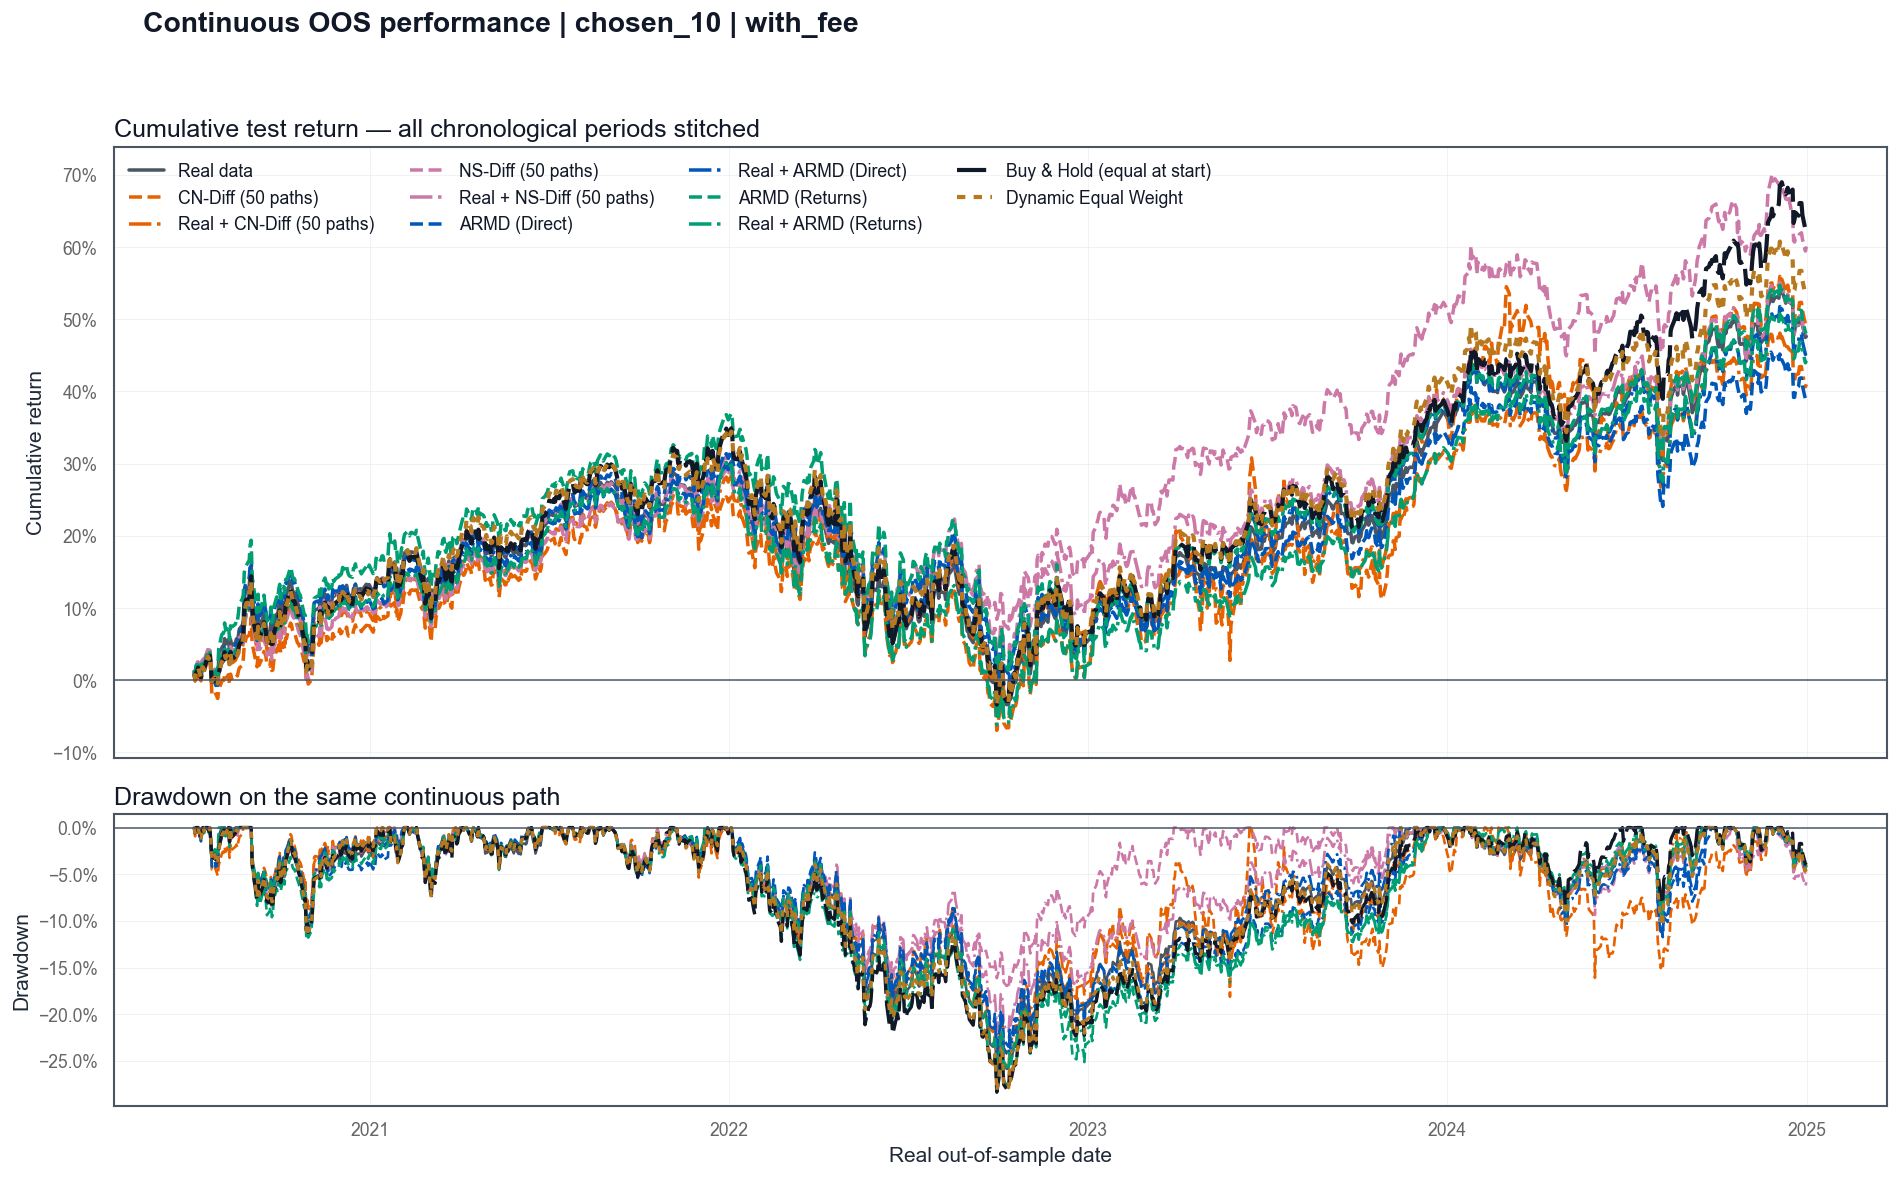

In [8]:
if HAS_CONTINUOUS:
    continuous_curves['date'] = pd.to_datetime(continuous_curves['date'])
    fig, (return_axis, drawdown_axis) = plt.subplots(
        2,
        1,
        figsize=(16, 10),
        sharex=True,
        gridspec_kw={'height_ratios': [2.1, 1]},
    )
    for group in GROUP_ORDER:
        group_curves = continuous_curves.loc[
            continuous_curves['group'] == group
        ]
        seed_curves = (
            group_curves.pivot(index='date', columns='seed', values='growth_of_one')
            .sort_index()
        )
        dates = seed_curves.index.to_pydatetime()
        returns = seed_curves - 1.0
        drawdowns = seed_curves.divide(seed_curves.cummax()).subtract(1.0)
        color = GROUP_COLORS[group]
        label = GROUP_LABELS[group]
        if seed_curves.shape[1] > 1:
            return_axis.fill_between(
                dates,
                returns.min(axis=1).to_numpy(),
                returns.max(axis=1).to_numpy(),
                color=color,
                alpha=0.12,
                linewidth=0,
            )
        return_axis.plot(
            dates,
            returns.mean(axis=1),
            color=color,
            linewidth=2.5 if group in BENCHMARK_GROUPS else 2.1,
            linestyle=GROUP_LINESTYLES[group],
            label=label,
        )
        if seed_curves.shape[1] > 1:
            drawdown_axis.fill_between(
                dates,
                drawdowns.min(axis=1).to_numpy(),
                drawdowns.max(axis=1).to_numpy(),
                color=color,
                alpha=0.10,
                linewidth=0,
            )
        drawdown_axis.plot(
            dates,
            drawdowns.mean(axis=1),
            color=color,
            linewidth=2.0 if group in BENCHMARK_GROUPS else 1.6,
            linestyle=GROUP_LINESTYLES[group],
        )

    return_axis.axhline(0, color='#4B5563', linewidth=0.9)
    return_axis.set_title('Cumulative test return — all chronological periods stitched', loc='left')
    return_axis.set_ylabel('Cumulative return')
    return_axis.yaxis.set_major_formatter(PercentFormatter(1.0))
    return_axis.legend(loc='upper left', ncol=4, frameon=False)
    drawdown_axis.axhline(0, color='#4B5563', linewidth=0.9)
    drawdown_axis.set_title('Drawdown on the same continuous path', loc='left')
    drawdown_axis.set_ylabel('Drawdown')
    drawdown_axis.set_xlabel('Real out-of-sample date')
    drawdown_axis.yaxis.set_major_formatter(PercentFormatter(1.0))
    drawdown_axis.xaxis.set_major_locator(mdates.YearLocator())
    drawdown_axis.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    fig.suptitle(
        f'Continuous OOS performance | {PLOT_TICKER_GROUP} | {PLOT_COMMISSION}',
        x=0.08,
        ha='left',
        fontsize=17,
        fontweight='bold',
    )
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()

### Continuous OOS performance by market block

The same continuous OOS observations are split at **2022-01-04** and **2022-10-13**. Each block is rebased to one only for its return, CAGR, Sharpe, volatility, and drawdown calculations; portfolio holdings and the recorded daily turnover are not reset at either breakpoint.


In [9]:
REGIME_BREAKS = pd.DatetimeIndex(['2022-01-04', '2022-10-13'])


def summarize_performance(frame):
    return (
        frame.groupby(['group', 'agent'], sort=False, as_index=False)
        .agg(
            Runs=('seed', 'nunique'),
            Return=('cumulative_return', 'mean'),
            Return_SD=('cumulative_return', 'std'),
            CAGR=('cagr', 'mean'),
            Sharpe=('sharpe', 'mean'),
            Sharpe_SD=('sharpe', 'std'),
            Sortino=('sortino', 'mean'),
            Calmar=('calmar', 'mean'),
            Volatility=('annualized_volatility', 'mean'),
            Max_drawdown=('max_drawdown', 'mean'),
            Turnover=('turnover', 'mean'),
        )
        .assign(_order=lambda table: table['group'].map(GROUP_ORDER.index))
        .sort_values('_order')
        .drop(columns=['group', '_order'])
        .rename(
            columns={
                'agent': 'Training data',
                'Return_SD': 'Return SD',
                'Sharpe_SD': 'Sharpe SD',
                'Max_drawdown': 'Max drawdown',
            }
        )
    )


PERFORMANCE_FORMATS = {
    'Return': '{:.2%}',
    'Return SD': '{:.2%}',
    'CAGR': '{:.2%}',
    'Sharpe': '{:.3f}',
    'Sharpe SD': '{:.3f}',
    'Sortino': '{:.3f}',
    'Calmar': '{:.3f}',
    'Volatility': '{:.2%}',
    'Max drawdown': '{:.2%}',
    'Turnover': '{:.3f}',
}

if HAS_CONTINUOUS:
    continuous_daily['date'] = pd.to_datetime(continuous_daily['date'])
    available_dates = pd.DatetimeIndex(sorted(continuous_daily['date'].unique()))
    if any(breakpoint not in available_dates for breakpoint in REGIME_BREAKS):
        missing = [
            date.strftime('%Y-%m-%d')
            for date in REGIME_BREAKS
            if date not in available_dates
        ]
        raise ValueError(f'Regime breakpoints are not OOS trading dates: {missing}')

    regime_edges = [available_dates.min(), *REGIME_BREAKS, available_dates.max() + pd.Timedelta(days=1)]
    REGIME_SPECS = []
    for block_number, (start, end) in enumerate(
        zip(regime_edges[:-1], regime_edges[1:]), start=1
    ):
        block_dates = available_dates[(available_dates >= start) & (available_dates < end)]
        REGIME_SPECS.append(
            {
                'block': f'Block {block_number}',
                'start': pd.Timestamp(start),
                'end': pd.Timestamp(end),
                'first_date': block_dates.min(),
                'last_date': block_dates.max(),
                'label': (
                    f'Block {block_number} | '
                    f'{block_dates.min():%Y-%m-%d} – {block_dates.max():%Y-%m-%d}'
                ),
            }
        )

    regime_metric_rows = []
    regime_curve_rows = []
    for spec in REGIME_SPECS:
        block_daily = continuous_daily.loc[
            (continuous_daily['date'] >= spec['start'])
            & (continuous_daily['date'] < spec['end'])
        ]
        for (group, agent, seed), run in block_daily.groupby(
            ['group', 'agent', 'seed'], sort=False
        ):
            run = run.sort_values('date')
            daily_returns = run['daily_return'].to_numpy(dtype=float)
            turnovers = run['turnover'].to_numpy(dtype=float)
            values = np.concatenate(
                [[1.0], np.cumprod(1.0 + daily_returns, dtype=float)]
            )
            regime_metric_rows.append(
                {
                    'block': spec['block'],
                    'block_label': spec['label'],
                    'first_date': spec['first_date'],
                    'last_date': spec['last_date'],
                    'group': group,
                    'agent': agent,
                    'seed': seed,
                    'test_days': len(run),
                    **benchmark_metrics(values, turnovers),
                }
            )
            for date, growth in zip(run['date'], values[1:]):
                regime_curve_rows.append(
                    {
                        'block': spec['block'],
                        'block_label': spec['label'],
                        'date': date,
                        'group': group,
                        'agent': agent,
                        'seed': seed,
                        'growth_of_one': float(growth),
                    }
                )

    regime_metrics = pd.DataFrame(regime_metric_rows)
    regime_curves = pd.DataFrame(regime_curve_rows)
    for spec in REGIME_SPECS:
        block_summary = summarize_performance(
            regime_metrics.loc[regime_metrics['block'] == spec['block']]
        )
        show_table(
            block_summary,
            caption=(
                f"Continuous OOS performance — {spec['label']} "
                '(policy means across seeds; deterministic benchmarks)'
            ),
            formats=PERFORMANCE_FORMATS,
            highlight=['Sharpe', 'Sortino', 'Calmar'],
        )


Training data,Runs,Return,Return SD,CAGR,Sharpe,Sharpe SD,Sortino,Calmar,Volatility,Max drawdown,Turnover
Real data,1,30.28%,—,19.23%,1.385,—,2.021,1.857,13.35%,-10.36%,0.020
CN-Diff (50 paths),1,25.39%,—,16.24%,1.178,—,1.693,1.917,13.55%,-8.47%,0.029
Real + CN-Diff (50 paths),1,28.29%,—,18.01%,1.361,—,1.986,2.026,12.77%,-8.89%,0.018
NS-Diff (50 paths),1,29.32%,—,18.64%,1.371,—,1.991,1.744,13.10%,-10.69%,0.019
Real + NS-Diff (50 paths),1,31.28%,—,19.84%,1.437,—,2.080,2.006,13.21%,-9.89%,0.018
ARMD (Direct),1,31.81%,—,20.16%,1.399,—,2.075,1.872,13.81%,-10.77%,0.021
Real + ARMD (Direct),1,30.06%,—,19.10%,1.437,—,2.117,1.946,12.73%,-9.81%,0.019
ARMD (Returns),1,36.97%,—,23.27%,1.561,—,2.295,1.974,14.04%,-11.79%,0.018
Real + ARMD (Returns),1,29.82%,—,18.95%,1.429,—,2.091,1.867,12.72%,-10.15%,0.019
Buy & Hold (equal at start),1,34.89%,—,22.02%,1.430,—,2.103,1.960,14.68%,-11.23%,0.003


Training data,Runs,Return,Return SD,CAGR,Sharpe,Sharpe SD,Sortino,Calmar,Volatility,Max drawdown,Turnover
Real data,1,-25.84%,—,-32.04%,-1.769,—,-2.255,-1.224,20.62%,-26.18%,0.015
CN-Diff (50 paths),1,-25.50%,—,-31.65%,-1.763,—,-2.237,-1.227,20.38%,-25.79%,0.012
Real + CN-Diff (50 paths),1,-24.06%,—,-29.93%,-1.649,—,-2.117,-1.224,20.31%,-24.45%,0.018
NS-Diff (50 paths),1,-17.21%,—,-21.65%,-1.543,—,-2.011,-1.258,15.07%,-17.21%,0.022
Real + NS-Diff (50 paths),1,-21.86%,—,-27.29%,-1.570,—,-2.014,-1.249,19.12%,-21.86%,0.017
ARMD (Direct),1,-23.49%,—,-29.25%,-1.580,—,-2.018,-1.240,20.55%,-23.59%,0.016
Real + ARMD (Direct),1,-24.35%,—,-30.27%,-1.647,—,-2.100,-1.239,20.59%,-24.44%,0.014
ARMD (Returns),1,-25.97%,—,-32.20%,-1.643,—,-2.096,-1.237,22.14%,-26.03%,0.017
Real + ARMD (Returns),1,-27.51%,—,-34.01%,-1.840,—,-2.337,-1.226,21.34%,-27.74%,0.014
Buy & Hold (equal at start),1,-27.99%,—,-34.58%,-1.731,—,-2.200,-1.219,22.97%,-28.37%,0.000


Training data,Runs,Return,Return SD,CAGR,Sharpe,Sharpe SD,Sortino,Calmar,Volatility,Max drawdown,Turnover
Real data,1,52.82%,—,21.15%,1.497,—,2.337,2.222,13.42%,-9.52%,0.014
CN-Diff (50 paths),1,60.14%,—,23.74%,1.094,—,1.647,1.475,21.60%,-16.10%,0.021
Real + CN-Diff (50 paths),1,44.74%,—,18.21%,1.299,—,2.011,2.091,13.59%,-8.71%,0.016
NS-Diff (50 paths),1,49.52%,—,19.96%,1.533,—,2.349,2.096,12.37%,-9.52%,0.017
Real + NS-Diff (50 paths),1,44.15%,—,17.99%,1.288,—,1.985,1.845,13.56%,-9.75%,0.013
ARMD (Direct),1,38.06%,—,15.71%,1.115,—,1.704,1.338,13.96%,-11.74%,0.015
Real + ARMD (Direct),1,47.72%,—,19.30%,1.362,—,2.078,1.674,13.64%,-11.53%,0.015
ARMD (Returns),1,46.33%,—,18.79%,1.258,—,1.956,1.618,14.53%,-11.61%,0.013
Real + ARMD (Returns),1,53.29%,—,21.32%,1.474,—,2.288,2.250,13.75%,-9.47%,0.014
Buy & Hold (equal at start),1,66.99%,—,26.11%,1.688,—,2.653,2.987,14.36%,-8.74%,0.000


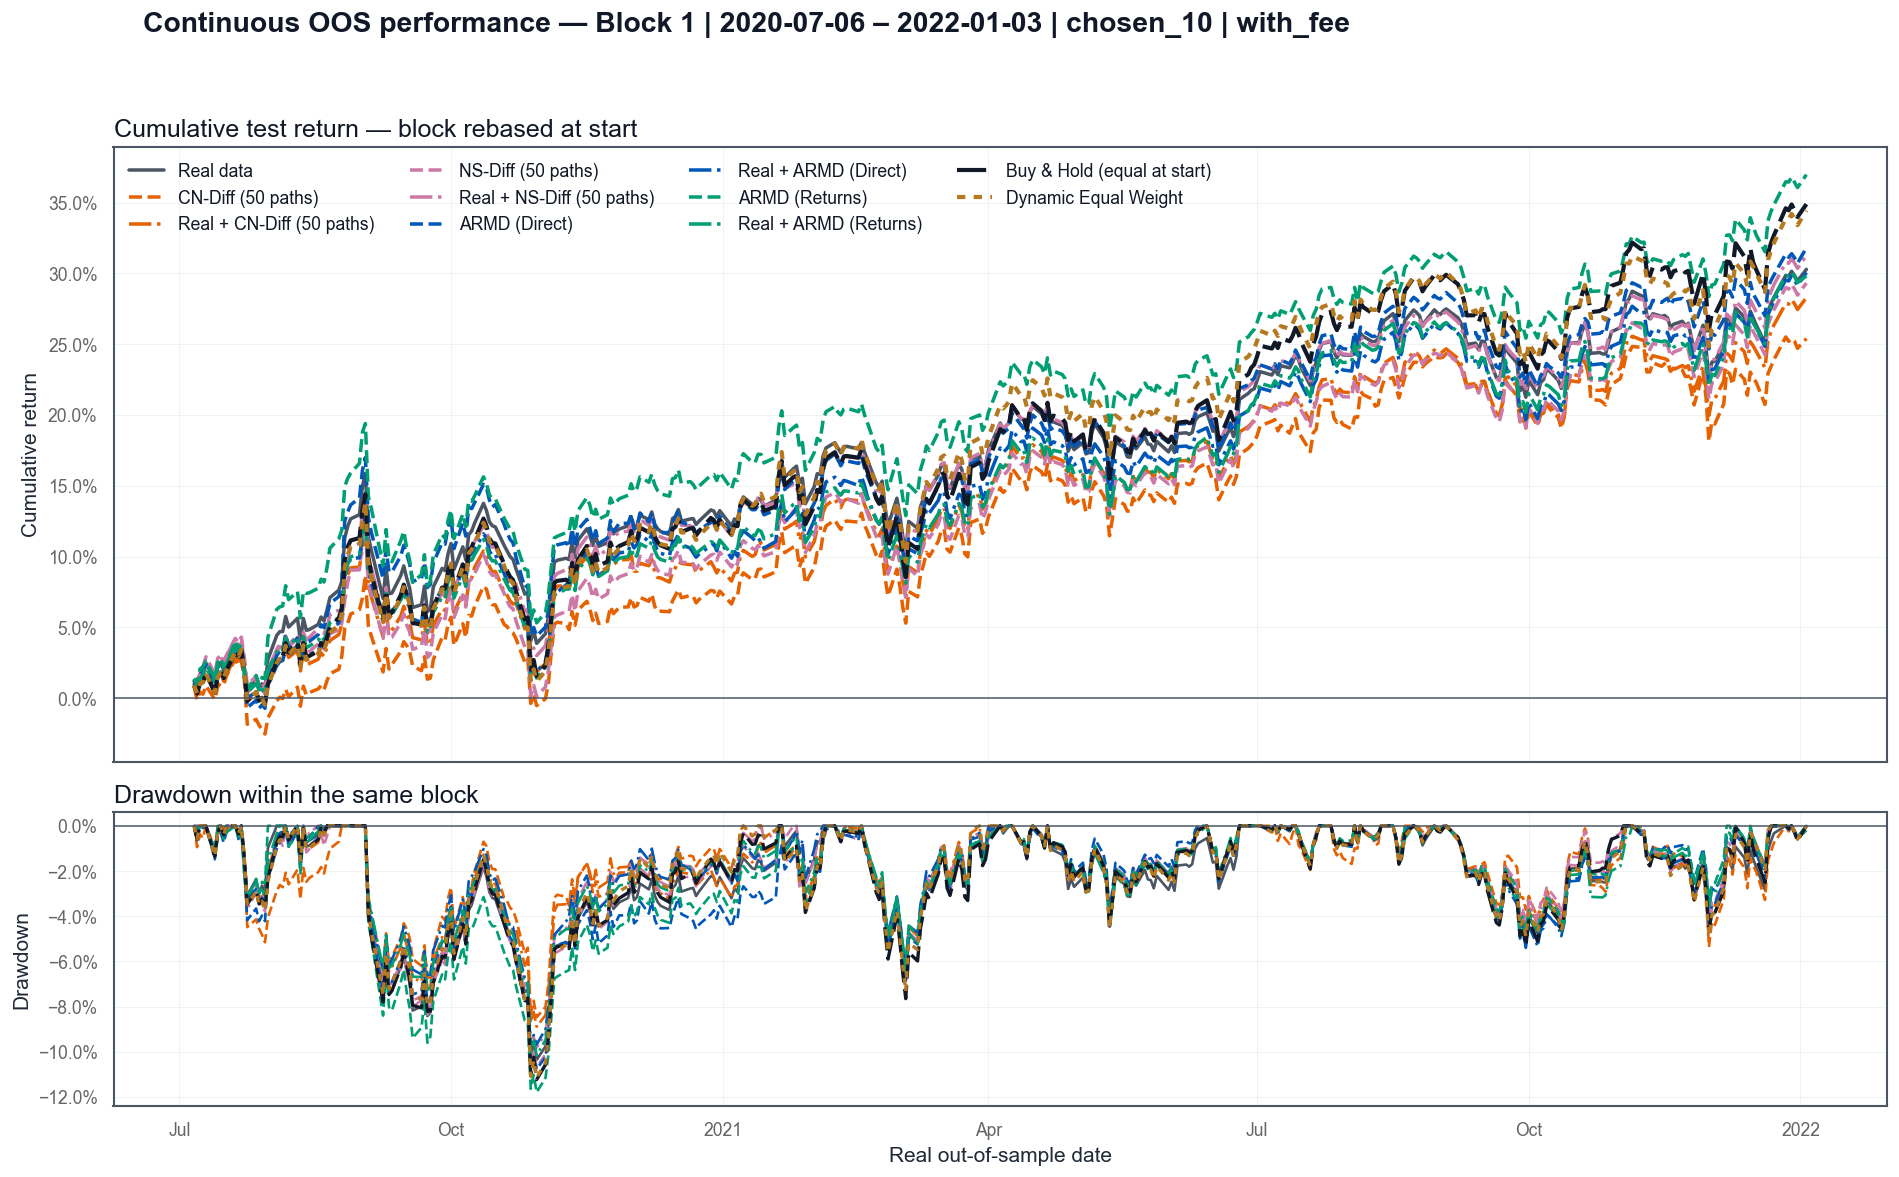

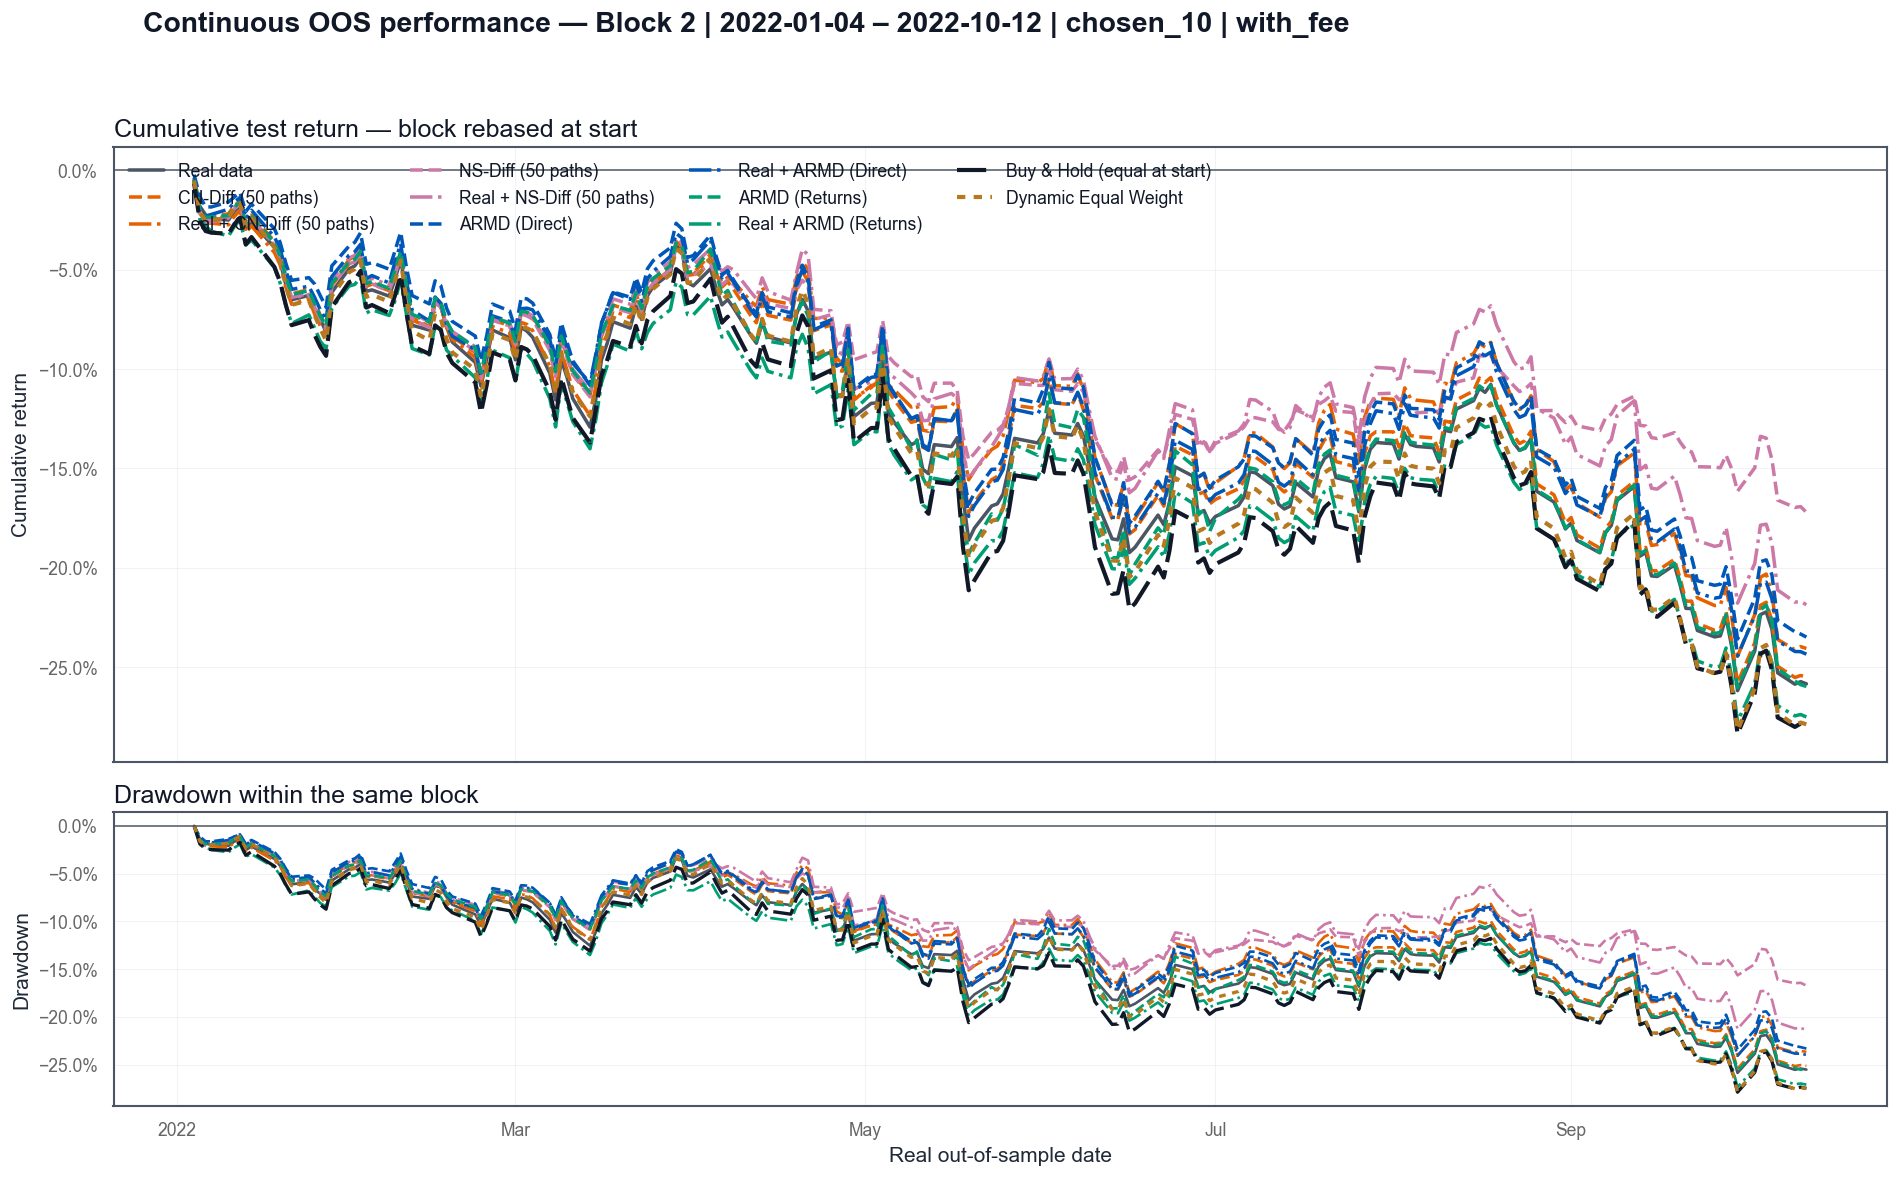

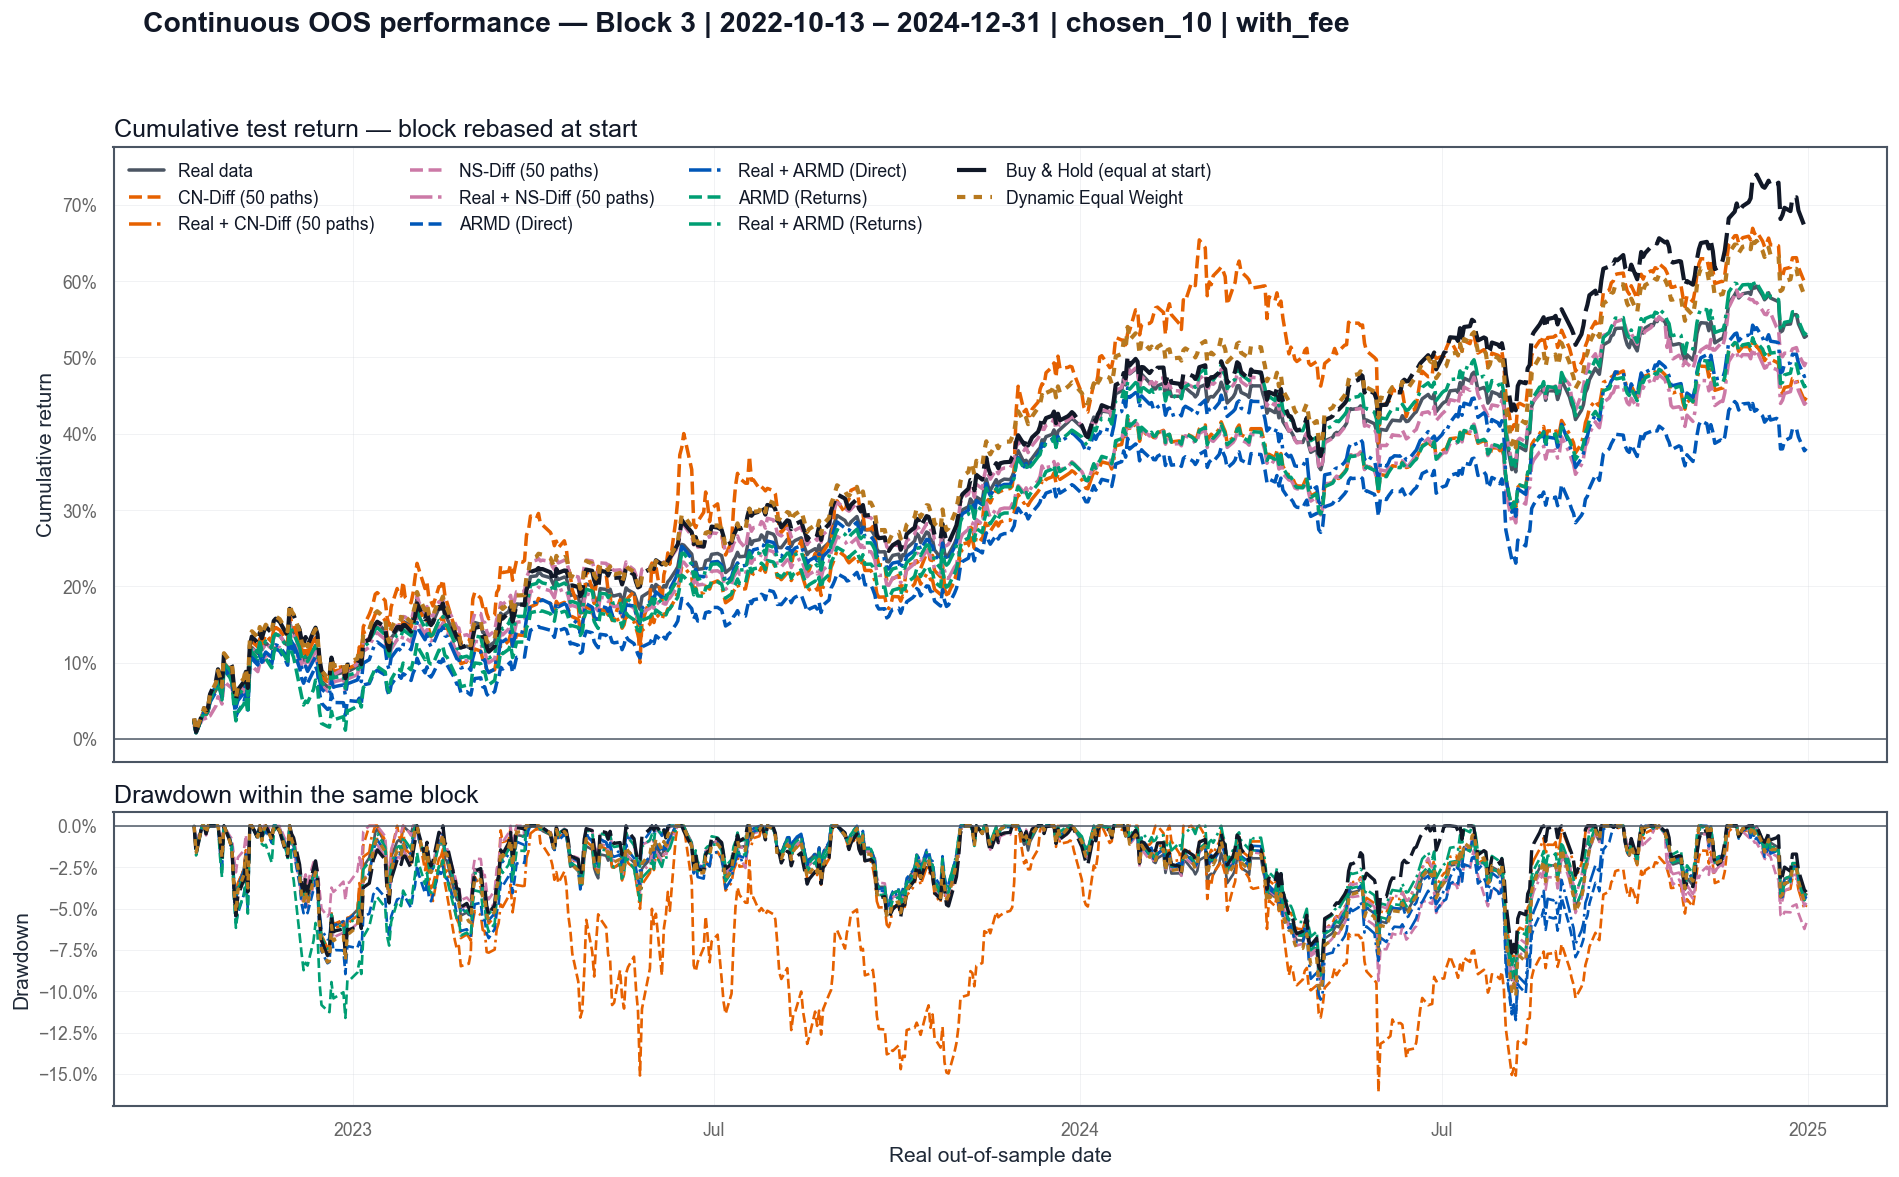

In [10]:
if HAS_CONTINUOUS:
    for spec in REGIME_SPECS:
        block_curves = regime_curves.loc[
            regime_curves['block'] == spec['block']
        ]
        fig, (return_axis, drawdown_axis) = plt.subplots(
            2,
            1,
            figsize=(16, 10),
            sharex=True,
            gridspec_kw={'height_ratios': [2.1, 1]},
        )
        for group in GROUP_ORDER:
            group_curves = block_curves.loc[block_curves['group'] == group]
            seed_curves = (
                group_curves.pivot(index='date', columns='seed', values='growth_of_one')
                .sort_index()
            )
            dates = seed_curves.index.to_pydatetime()
            returns = seed_curves - 1.0
            drawdowns = seed_curves.divide(seed_curves.cummax()).subtract(1.0)
            color = GROUP_COLORS[group]
            label = GROUP_LABELS[group]
            if seed_curves.shape[1] > 1:
                return_axis.fill_between(
                    dates,
                    returns.min(axis=1).to_numpy(),
                    returns.max(axis=1).to_numpy(),
                    color=color,
                    alpha=0.12,
                    linewidth=0,
                )
            return_axis.plot(
                dates,
                returns.mean(axis=1),
                color=color,
                linewidth=2.5 if group in BENCHMARK_GROUPS else 2.1,
                linestyle=GROUP_LINESTYLES[group],
                label=label,
            )
            if seed_curves.shape[1] > 1:
                drawdown_axis.fill_between(
                    dates,
                    drawdowns.min(axis=1).to_numpy(),
                    drawdowns.max(axis=1).to_numpy(),
                    color=color,
                    alpha=0.10,
                    linewidth=0,
                )
            drawdown_axis.plot(
                dates,
                drawdowns.mean(axis=1),
                color=color,
                linewidth=2.0 if group in BENCHMARK_GROUPS else 1.6,
                linestyle=GROUP_LINESTYLES[group],
            )

        return_axis.axhline(0, color='#4B5563', linewidth=0.9)
        return_axis.set_title('Cumulative test return — block rebased at start', loc='left')
        return_axis.set_ylabel('Cumulative return')
        return_axis.yaxis.set_major_formatter(PercentFormatter(1.0))
        return_axis.legend(loc='upper left', ncol=4, frameon=False)
        drawdown_axis.axhline(0, color='#4B5563', linewidth=0.9)
        drawdown_axis.set_title('Drawdown within the same block', loc='left')
        drawdown_axis.set_ylabel('Drawdown')
        drawdown_axis.set_xlabel('Real out-of-sample date')
        drawdown_axis.yaxis.set_major_formatter(PercentFormatter(1.0))
        date_locator = mdates.AutoDateLocator(minticks=4, maxticks=8)
        drawdown_axis.xaxis.set_major_locator(date_locator)
        drawdown_axis.xaxis.set_major_formatter(mdates.ConciseDateFormatter(date_locator))
        fig.suptitle(
            f"Continuous OOS performance — {spec['label']} | "
            f'{PLOT_TICKER_GROUP} | {PLOT_COMMISSION}',
            x=0.08,
            ha='left',
            fontsize=17,
            fontweight='bold',
        )
        fig.tight_layout(rect=(0, 0, 1, 0.95))
        plt.show()


## 5. Every test period at a glance

The heatmap shows the exact mean return for every chronological test period and training group. Columns use calendar quarters instead of internal window IDs; the table summarizes stability across periods.

Training data,Periods,Positive periods,Median return,Worst return,Return IQR,Median Sharpe,Mean turnover
Real data,18,77.8%,2.20%,-11.74%,5.16%,0.777,0.016
CN-Diff (50 paths),18,66.7%,2.63%,-11.45%,10.11%,0.802,0.022
Real + CN-Diff (50 paths),18,66.7%,2.45%,-10.18%,6.70%,0.904,0.017
NS-Diff (50 paths),18,66.7%,2.81%,-8.35%,6.86%,0.948,0.018
Real + NS-Diff (50 paths),18,72.2%,2.34%,-8.78%,6.09%,0.809,0.015
ARMD (Direct),18,72.2%,1.68%,-11.11%,5.20%,0.497,0.017
Real + ARMD (Direct),18,77.8%,2.50%,-11.78%,4.80%,0.784,0.016
ARMD (Returns),18,77.8%,2.22%,-12.10%,5.10%,0.777,0.015
Real + ARMD (Returns),18,72.2%,3.24%,-12.09%,5.97%,0.893,0.016
Buy & Hold (equal at start),18,72.2%,4.49%,-13.52%,6.72%,1.312,0.001


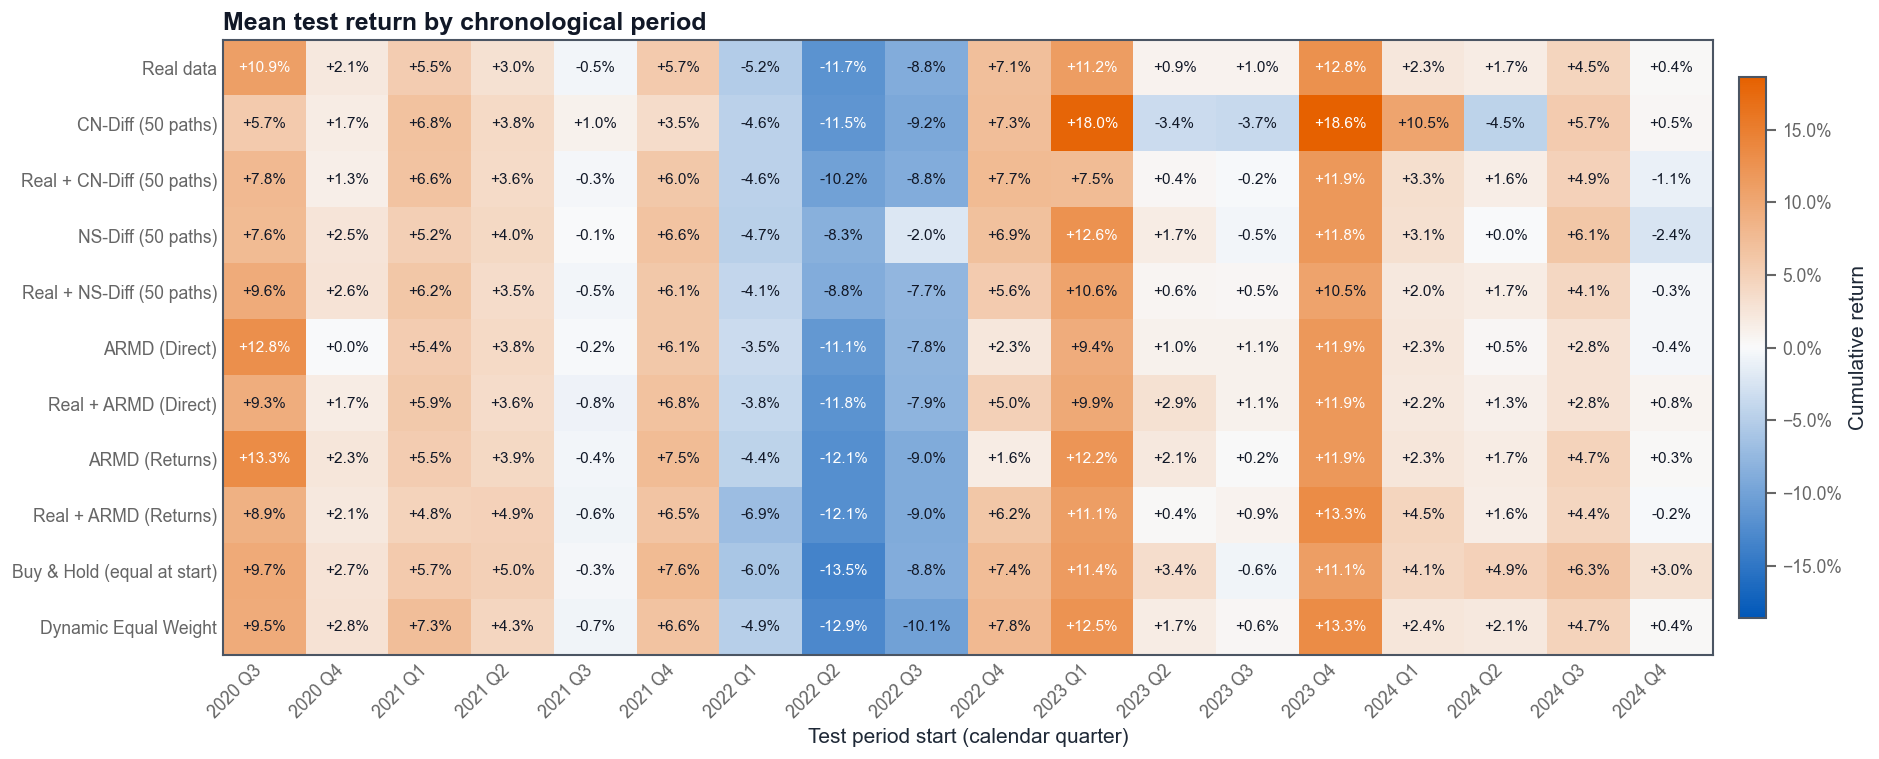

In [11]:
if HAS_CONTINUOUS:
    continuous_windows['test_start'] = pd.to_datetime(continuous_windows['test_start'])
    window_means = (
        continuous_windows.groupby(
            ['group', 'agent', 'test_start'], sort=False, as_index=False
        )
        .agg(
            Return=('cumulative_return', 'mean'),
            Sharpe=('sharpe', 'mean'),
            Turnover=('turnover', 'mean'),
        )
    )
    stability = (
        window_means.groupby(['group', 'agent'], sort=False, as_index=False)
        .agg(
            Periods=('test_start', 'size'),
            Positive_rate=('Return', lambda values: (values > 0).mean()),
            Median_return=('Return', 'median'),
            Worst_return=('Return', 'min'),
            Return_IQR=(
                'Return',
                lambda values: values.quantile(0.75) - values.quantile(0.25),
            ),
            Median_Sharpe=('Sharpe', 'median'),
            Mean_turnover=('Turnover', 'mean'),
        )
        .assign(_order=lambda frame: frame['group'].map(GROUP_ORDER.index))
        .sort_values('_order')
        .drop(columns=['group', '_order'])
        .rename(
            columns={
                'agent': 'Training data',
                'Positive_rate': 'Positive periods',
                'Median_return': 'Median return',
                'Worst_return': 'Worst return',
                'Return_IQR': 'Return IQR',
                'Median_Sharpe': 'Median Sharpe',
                'Mean_turnover': 'Mean turnover',
            }
        )
    )
    show_table(
        stability,
        caption='Test-period stability (period metrics averaged across seeds first)',
        formats={
            'Positive periods': '{:.1%}',
            'Median return': '{:.2%}',
            'Worst return': '{:.2%}',
            'Return IQR': '{:.2%}',
            'Median Sharpe': '{:.3f}',
            'Mean turnover': '{:.3f}',
        },
        highlight=['Positive periods'],
    )

    return_matrix = (
        window_means.pivot(index='group', columns='test_start', values='Return')
        .reindex(index=GROUP_ORDER)
        .sort_index(axis=1)
    )
    matrix_values = return_matrix.to_numpy(dtype=float)
    return_limit = float(np.nanmax(np.abs(matrix_values)))
    if not np.isfinite(return_limit) or return_limit == 0:
        return_limit = 1.0
    return_cmap = LinearSegmentedColormap.from_list(
        'return_diverging', ['#0057B8', '#F9FAFB', '#E66100']
    )
    return_norm = TwoSlopeNorm(vmin=-return_limit, vcenter=0, vmax=return_limit)
    fig, axis = plt.subplots(figsize=(17, 6.5))
    image = axis.imshow(
        matrix_values,
        aspect='auto',
        cmap=return_cmap,
        norm=return_norm,
    )
    for row_index in range(matrix_values.shape[0]):
        for column_index in range(matrix_values.shape[1]):
            value = matrix_values[row_index, column_index]
            if np.isfinite(value):
                axis.text(
                    column_index,
                    row_index,
                    f'{value:+.1%}',
                    ha='center',
                    va='center',
                    fontsize=9.2,
                    color='white' if abs(value) > 0.58 * return_limit else '#111827',
                )
    quarter_labels = [
        f'{date.year} Q{date.quarter}' for date in return_matrix.columns
    ]
    axis.set_xticks(range(len(quarter_labels)), quarter_labels, rotation=45, ha='right')
    axis.set_yticks(
        range(len(GROUP_ORDER)),
        [GROUP_LABELS[group] for group in GROUP_ORDER],
    )
    axis.tick_params(axis='both', length=0)
    axis.grid(False)
    axis.set_xlabel('Test period start (calendar quarter)')
    axis.set_title(
        'Mean test return by chronological period', loc='left', fontweight='bold'
    )
    colorbar = fig.colorbar(image, ax=axis, pad=0.015, shrink=0.88)
    colorbar.set_label('Cumulative return')
    colorbar.ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    fig.tight_layout()
    plt.show()

## 6. Continuous portfolio weighting

Each panel is a stacked-area view of actual end-of-day weights, matching the original Synthetic vs Real notebook: cross-seed means for PPO policies and deterministic weights for the two benchmarks. Asset colors remain fixed across all panels, and holdings carry across chronological test boundaries.


Training data,Runs,Trading days,Min weight sum,Max weight sum,Max |sum − 1|
Real data,1,1131,1.000000,1.000000,1.60e-07
CN-Diff (50 paths),1,1131,1.000000,1.000000,1.72e-07
Real + CN-Diff (50 paths),1,1131,1.000000,1.000000,1.71e-07
NS-Diff (50 paths),1,1131,1.000000,1.000000,1.42e-07
Real + NS-Diff (50 paths),1,1131,1.000000,1.000000,1.49e-07
ARMD (Direct),1,1131,1.000000,1.000000,1.49e-07
Real + ARMD (Direct),1,1131,1.000000,1.000000,1.56e-07
ARMD (Returns),1,1131,1.000000,1.000000,1.79e-07
Real + ARMD (Returns),1,1131,1.000000,1.000000,1.38e-07
Buy & Hold (equal at start),1,1131,1.000000,1.000000,2.22e-16


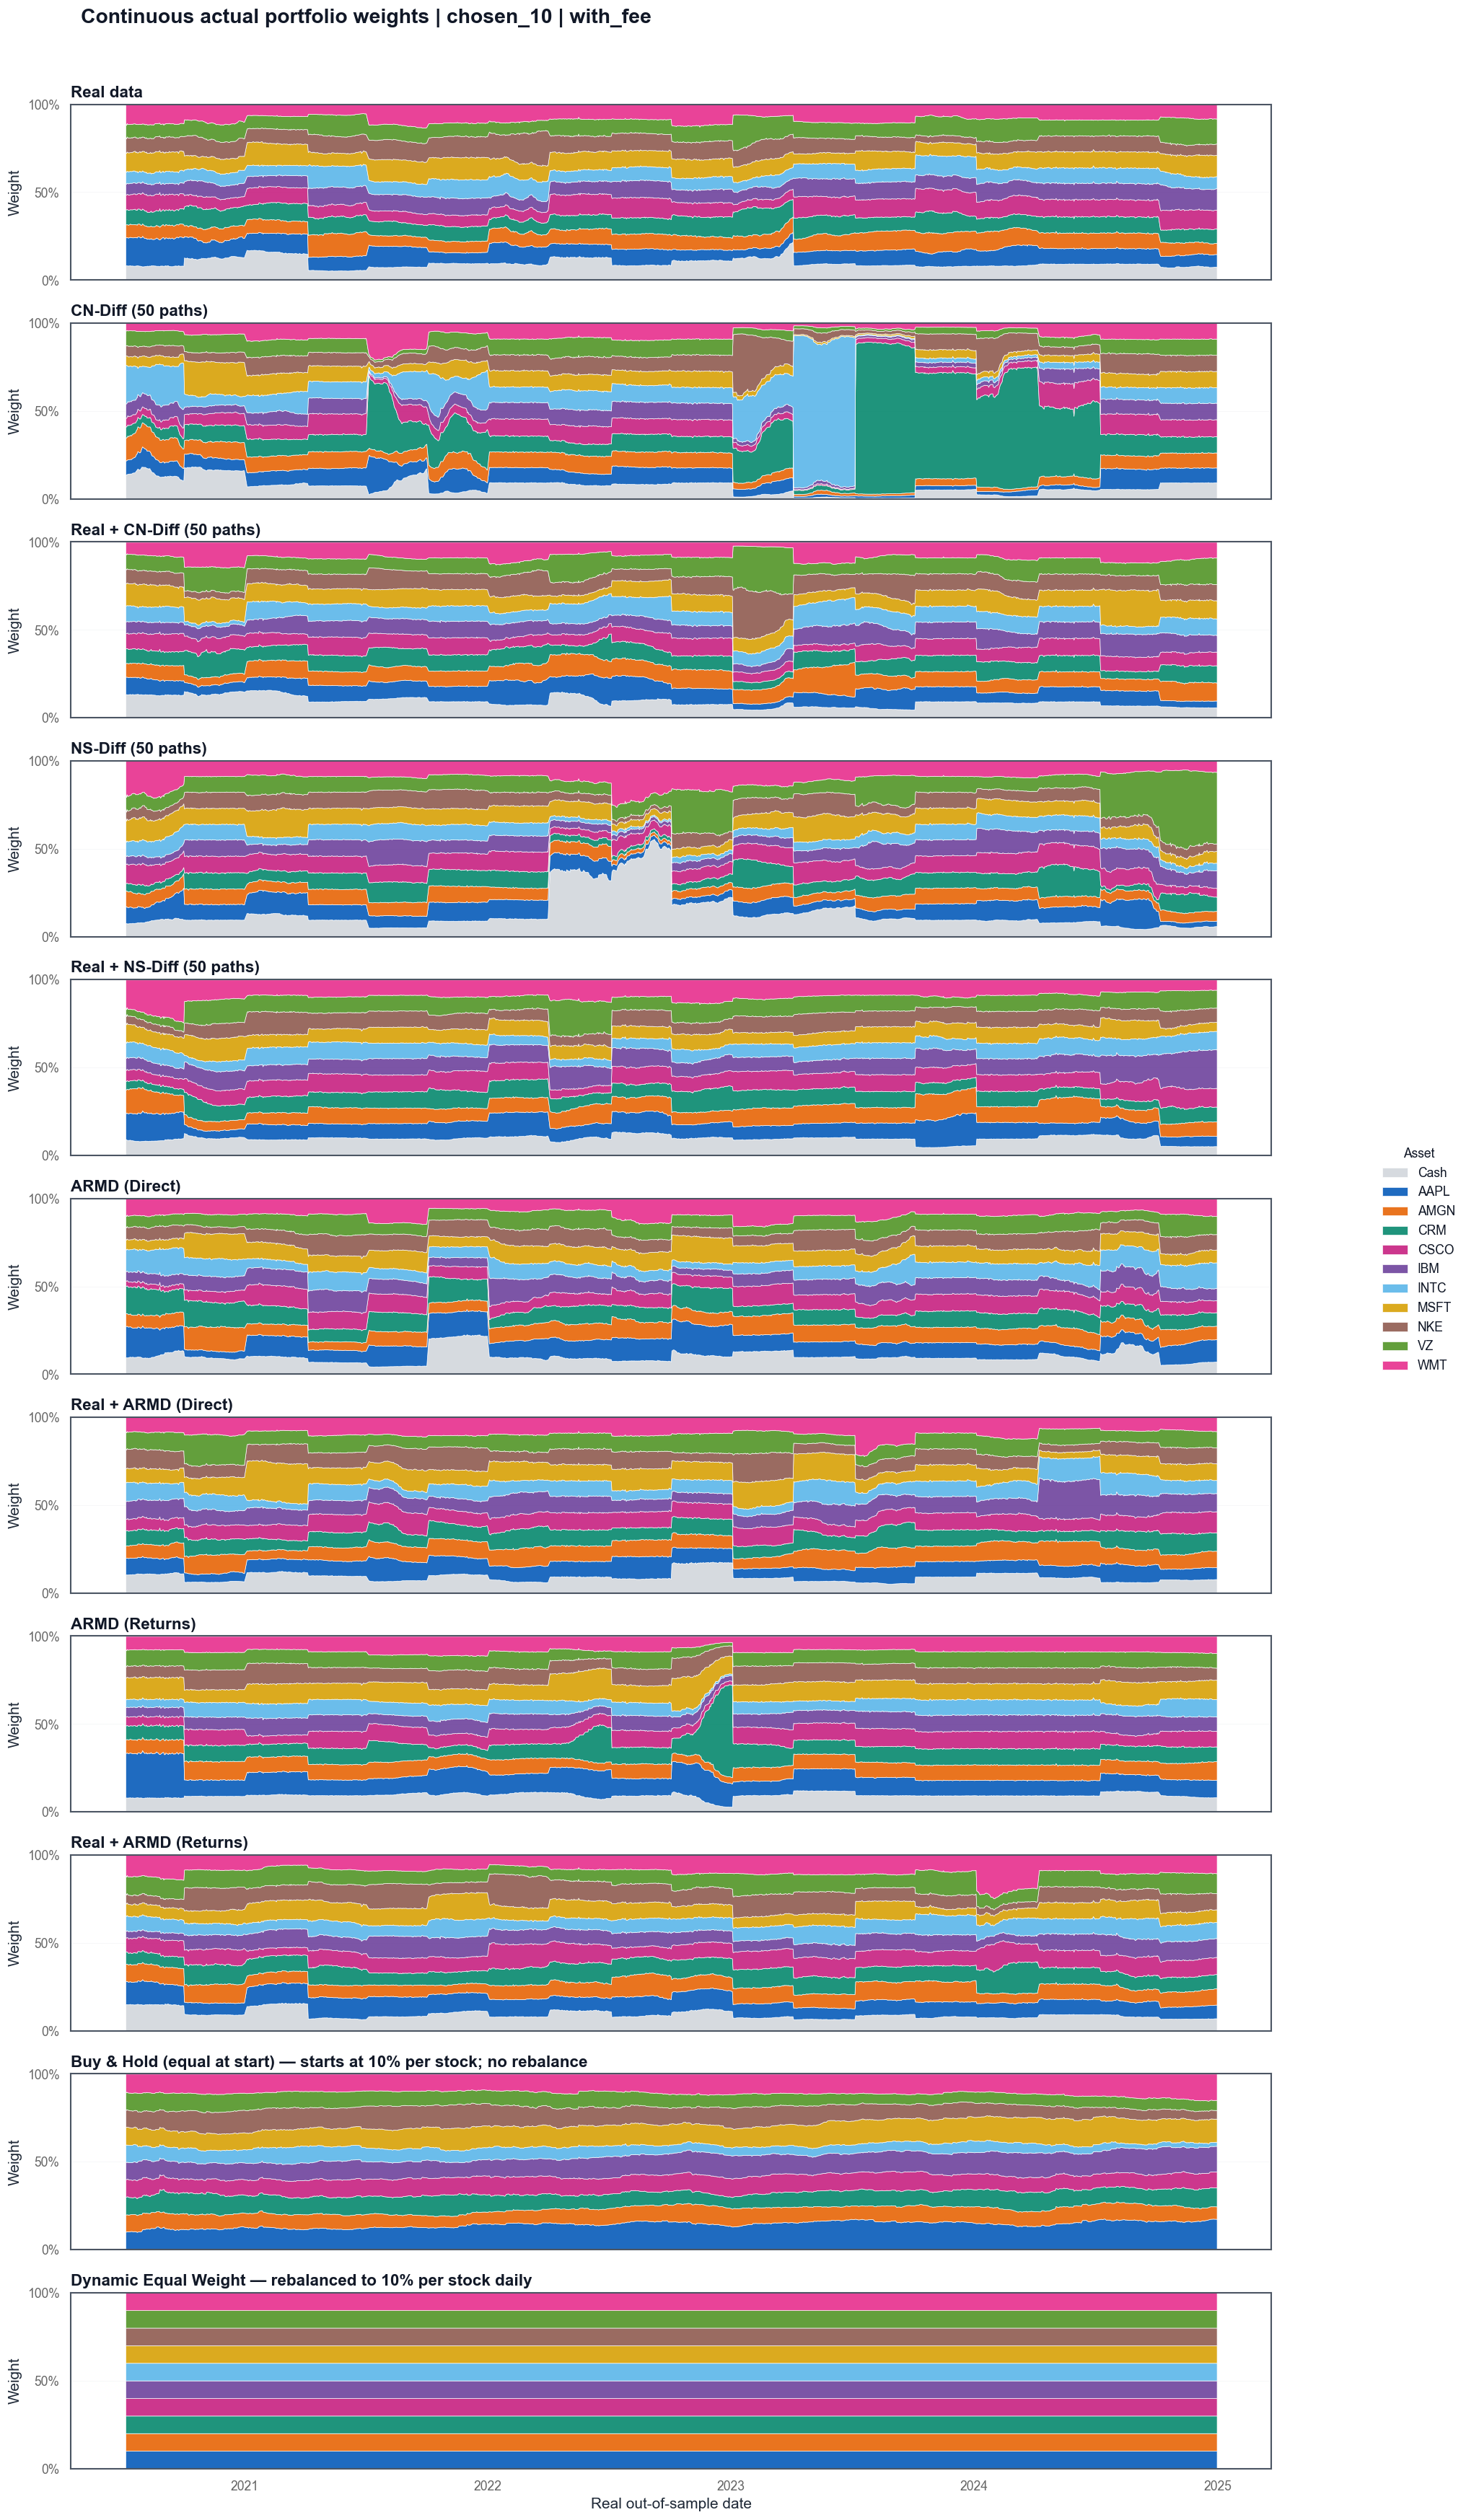

In [12]:
if HAS_CONTINUOUS:
    continuous_weights['date'] = pd.to_datetime(continuous_weights['date'])
    daily_weight_sums = (
        continuous_weights.groupby(
            ['group', 'agent', 'seed', 'date'], sort=False
        )['actual_weight']
        .sum()
        .reset_index(name='weight_sum')
    )
    weight_quality = (
        daily_weight_sums.groupby(['group', 'agent'], sort=False, as_index=False)
        .agg(
            Runs=('seed', 'nunique'),
            Trading_days=('date', 'nunique'),
            Min_weight_sum=('weight_sum', 'min'),
            Max_weight_sum=('weight_sum', 'max'),
            Max_sum_error=('weight_sum', lambda values: (values - 1.0).abs().max()),
        )
        .assign(_order=lambda frame: frame['group'].map(GROUP_ORDER.index))
        .sort_values('_order')
        .drop(columns=['group', '_order'])
        .rename(
            columns={
                'agent': 'Training data',
                'Trading_days': 'Trading days',
                'Min_weight_sum': 'Min weight sum',
                'Max_weight_sum': 'Max weight sum',
                'Max_sum_error': 'Max |sum − 1|',
            }
        )
    )
    show_table(
        weight_quality,
        caption='Continuous weighting coverage and sum-to-one check',
        formats={
            'Min weight sum': '{:.6f}',
            'Max weight sum': '{:.6f}',
            'Max |sum − 1|': '{:.2e}',
        },
    )

    mean_weights = (
        continuous_weights.groupby(
            ['group', 'agent', 'date', 'asset'], sort=False, as_index=False
        )['actual_weight']
        .mean()
    )
    assets = list(dict.fromkeys(mean_weights['asset']))
    assets = (['Cash'] if 'Cash' in assets else []) + sorted(
        asset for asset in assets if asset != 'Cash'
    )
    weight_palette = [
        '#D1D5DB',  # Cash
        '#0057B8',
        '#E66100',
        '#00856A',
        '#C51B7D',
        '#6A3D9A',
        '#56B4E9',
        '#D69E00',
        '#8C564B',
        '#4D9221',
        '#E7298A',
        '#7F3C8D',
        '#17A2B8',
        '#A6761D',
    ]
    if len(assets) > len(weight_palette):
        raise ValueError(
            f'Weight palette has {len(weight_palette)} colors for {len(assets)} assets'
        )
    asset_colors = weight_palette[:len(assets)]

    fig, axes = plt.subplots(
        len(GROUP_ORDER),
        1,
        figsize=(17, max(7, 2.7 * len(GROUP_ORDER))),
        sharex=True,
        sharey=True,
        squeeze=False,
    )
    axes = axes.ravel()
    for axis, group in zip(axes, GROUP_ORDER):
        pivot = (
            mean_weights.loc[mean_weights['group'] == group]
            .pivot(index='date', columns='asset', values='actual_weight')
            .sort_index()
            .reindex(columns=assets)
            .fillna(0.0)
        )
        if not np.allclose(pivot.sum(axis=1), 1.0, atol=1e-6):
            raise ValueError(f'Mean portfolio weights do not sum to one for {group}')
        axis.stackplot(
            pivot.index.to_pydatetime(),
            pivot.to_numpy(dtype=float).T,
            labels=assets,
            colors=asset_colors,
            alpha=0.88,
            linewidth=0.45,
            edgecolor='white',
        )
        panel_title = GROUP_LABELS[group]
        if group == 'buy_and_hold_equal_start':
            panel_title += f' — starts at {1 / len(benchmark_tickers):.0%} per stock; no rebalance'
        elif group == 'dynamic_equal_weight':
            panel_title += f' — rebalanced to {1 / len(benchmark_tickers):.0%} per stock daily'
        axis.set_title(panel_title, loc='left', fontsize=13.5, fontweight='bold')
        axis.set_ylabel('Weight')
        axis.set_ylim(0, 1)
        axis.set_yticks([0, 0.5, 1.0])
        axis.yaxis.set_major_formatter(PercentFormatter(1.0))
        axis.grid(axis='y', alpha=0.22)
        axis.grid(axis='x', visible=False)

    axes[-1].xaxis.set_major_locator(mdates.YearLocator())
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[-1].set_xlabel('Real out-of-sample date')
    handles, legend_labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        legend_labels,
        title='Asset',
        loc='center right',
        ncol=1,
        frameon=False,
    )
    fig.suptitle(
        f'Continuous actual portfolio weights | {PLOT_TICKER_GROUP} | {PLOT_COMMISSION}',
        x=0.06,
        ha='left',
        fontsize=17,
        fontweight='bold',
    )
    fig.tight_layout(rect=(0, 0, 0.88, 0.97))
    plt.show()


## 7. Paired robustness against real-only training

Each comparison is paired on the same calendar period, fee setting, and seed. Win rates show how often a synthetic or mixed-data policy beats the matching real-only policy rather than relying on one favorable period.

In [13]:
if artifacts is not None:
    paired = suite_slice(artifacts.paired_deltas)
    if not paired.empty:
        paired_summary = (
            paired.groupby(
                ['training_group', 'training_group_label'],
                sort=False,
                as_index=False,
            )
            .agg(
                Test_periods=('window_id', 'nunique'),
                Paired_runs=('seed', 'size'),
                Median_delta_return=('delta_cumulative_return', 'median'),
                Return_win_rate=(
                    'delta_cumulative_return',
                    lambda values: (values > 0).mean(),
                ),
                Median_delta_Sharpe=('delta_sharpe', 'median'),
                Sharpe_win_rate=('delta_sharpe', lambda values: (values > 0).mean()),
                Median_delta_turnover=('delta_turnover', 'median'),
            )
            .drop(columns=['training_group'])
            .rename(
                columns={
                    'training_group_label': 'Training data',
                    'Test_periods': 'Test periods',
                    'Paired_runs': 'Paired runs',
                    'Median_delta_return': 'Median Δ return',
                    'Return_win_rate': 'Return win rate',
                    'Median_delta_Sharpe': 'Median Δ Sharpe',
                    'Sharpe_win_rate': 'Sharpe win rate',
                    'Median_delta_turnover': 'Median Δ turnover',
                }
            )
            .sort_values('Sharpe win rate', ascending=False)
        )
        show_table(
            paired_summary,
            caption='Paired effects versus real-only training',
            formats={
                'Median Δ return': '{:+.2%}',
                'Return win rate': '{:.1%}',
                'Median Δ Sharpe': '{:+.3f}',
                'Sharpe win rate': '{:.1%}',
                'Median Δ turnover': '{:+.4f}',
            },
            highlight=['Sharpe win rate'],
        )

Training data,Test periods,Paired runs,Median Δ return,Return win rate,Median Δ Sharpe,Sharpe win rate,Median Δ turnover
NS-Diff (50 paths),18,18,+0.50%,61.1%,+0.129,61.1%,-0.0008
CN-Diff (50 paths),18,18,+0.18%,61.1%,+0.010,50.0%,+0.0006
Real + CN-Diff (50 paths),18,18,+0.11%,55.6%,+0.026,50.0%,-0.0001
ARMD (Direct),18,18,+0.04%,50.0%,+0.007,50.0%,+0.0002
Real + ARMD (Direct),18,18,-0.11%,44.4%,+0.027,50.0%,-0.0002
ARMD (Returns),18,18,+0.02%,55.6%,+0.035,50.0%,-0.0008
Real + NS-Diff (50 paths),18,18,-0.17%,38.9%,-0.063,38.9%,-0.0004
Real + ARMD (Returns),18,18,-0.13%,27.8%,-0.049,33.3%,-0.0000


## 8. Optional single-period learning diagnostic

This diagnostic is off by default because the report focuses on the complete OOS chain. When enabled, its title uses the calendar test range rather than the internal window ID.

In [14]:
SHOW_LEARNING_DIAGNOSTIC = False
DETAIL_GROUP = 'real_trained'

if HAS_CONTINUOUS and SHOW_LEARNING_DIAGNOSTIC:
    detail_row = continuous_windows.sort_values('test_start').iloc[-1]
    DETAIL_WINDOW = detail_row['window_id']
    figure, axes = plot_learning_curves(
        artifacts,
        window_id=DETAIL_WINDOW,
        ticker_group=PLOT_TICKER_GROUP,
        group=DETAIL_GROUP,
        commission_name=PLOT_COMMISSION,
    )
    test_start = pd.Timestamp(detail_row['test_start']).date()
    test_end = pd.Timestamp(detail_row['test_end']).date()
    figure.suptitle(
        f'Learning diagnostic | test {test_start} to {test_end} | '
        f'{GROUP_LABELS[DETAIL_GROUP]} | {PLOT_COMMISSION}',
        fontsize=16,
        fontweight='bold',
    )
    figure.tight_layout()
    plt.show()
else:
    print('Set SHOW_LEARNING_DIAGNOSTIC = True to inspect the latest test period.')

Set SHOW_LEARNING_DIAGNOSTIC = True to inspect the latest test period.


## Interpretation checklist

- Continuous return and weighting views carry portfolio value and holdings across chronological test boundaries.
- PPO return lines are cross-seed means with observed seed bands; equal-weight benchmarks are deterministic reference paths.
- Buy & Hold is equal-weighted once before the first test day; Dynamic Equal Weight rebalances at every OOS close and pays turnover costs.
- The stacked-area weighting panels include every saved test date and asset, using policy means across seeds and deterministic benchmark weights.
- The three market blocks reset only the displayed performance baseline; they do not reset portfolio holdings or daily turnover.
- Compare each synthetic or combined run with the same-period, same-fee, same-seed real-only policy.
- Treat synthetic validation as a diagnostic; checkpoint selection is based on real validation.
- Use the period heatmap and paired win-rate table to check whether improvements repeat instead of relying on one favorable period.
- Review turnover, drawdown, and portfolio weights together with return and Sharpe.
- Add new chronological windows and ticker groups to the JSON config before rerunning.
- Synthetic paths may use `data/synthetic/{train_start}_to_{val_end}/{ticker_group}/{dataset}/path_*.csv`; the existing period-level dataset layout remains supported as a fallback.